In [12]:
from google.colab import files

uploaded = files.upload()
# 上传train.csv test.csv example-submission.csv 三个文件

Saving example-submission.csv to example-submission.csv


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn

from pathlib import Path
from sklearn.base import clone
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

SEED = 42

train = pd.read_csv("/content/train.csv")
test = pd.read_csv("/content/test.csv")

print("scikit-learn:", sklearn.__version__)
print("Train shape:", train.shape)
print("Test shape:", test.shape)

print("\nTrain columns:", train.columns.tolist())
print("Test columns:", test.columns.tolist())

display(train.head())
display(test.head())

scikit-learn: 1.6.1
Train shape: (150000, 11)
Test shape: (50000, 10)

Train columns: ['RENT_APPROVAL_DATE', 'TOWN', 'BLOCK', 'STREET', 'FLAT_TYPE', 'FLAT_MODEL', 'FLOOR_AREA_SQM', 'FURNISHED', 'LEASE_COMMENCE_DATE', 'FEE', 'MONTHLY_RENT']
Test columns: ['RENT_APPROVAL_DATE', 'TOWN', 'BLOCK', 'STREET', 'FLAT_TYPE', 'FLAT_MODEL', 'FLOOR_AREA_SQM', 'FURNISHED', 'LEASE_COMMENCE_DATE', 'FEE']


,RENT_APPROVAL_DATE,TOWN,BLOCK,STREET,FLAT_TYPE,FLAT_MODEL,FLOOR_AREA_SQM,FURNISHED,LEASE_COMMENCE_DATE,FEE,MONTHLY_RENT
0,2021-01,punggol,604a,punggol road,4 room,model a,93.0,yes,2012,0.0,1800
1,2021-01,sengkang,290c,compassvale crescent,5 room,improved,110.0,yes,2001,0.0,2000
2,2021-01,queenstown,5,ghim moh road,3 room,improved,65.0,yes,1976,0.0,2000
3,2021-01,sengkang,436b,fernvale road,4 room,model a,96.0,yes,2010,0.0,1400
4,2021-01,sembawang,467b,admiralty drive,4 room,premium apartment,102.0,yes,2001,0.0,1800


,RENT_APPROVAL_DATE,TOWN,BLOCK,STREET,FLAT_TYPE,FLAT_MODEL,FLOOR_AREA_SQM,FURNISHED,LEASE_COMMENCE_DATE,FEE
0,2025-03,kallang/whampoa,74,Whampoa Drive,3-room,improved,66.0,yes,1981,0.0
1,2025-03,bukit timah,6,farrer road,4-room,improved,91.0,yes,1974,0.0
2,2025-03,pasir ris,755,Pasir Ris Street 71,4-room,model a,105.0,yes,1996,0.0
3,2025-03,punggol,299,punggol central,4-room,premium apartment,94.0,yes,2003,0.0
4,2025-03,tampines,869a,tampines avenue 8,4-room,model a,92.0,yes,2015,0.0


,missing
RENT_APPROVAL_DATE,0
FLOOR_AREA_SQM,0
LEASE_COMMENCE_DATE,0
TOWN,0
FLAT_TYPE,0
MONTHLY_RENT,0


,monthly_rent
count,150000.000000
mean,2719.036893
std,749.731096
min,300.000000
25%,2100.000000
50%,2700.000000
75%,3200.000000
max,7600.000000


完全重复的行数: 425


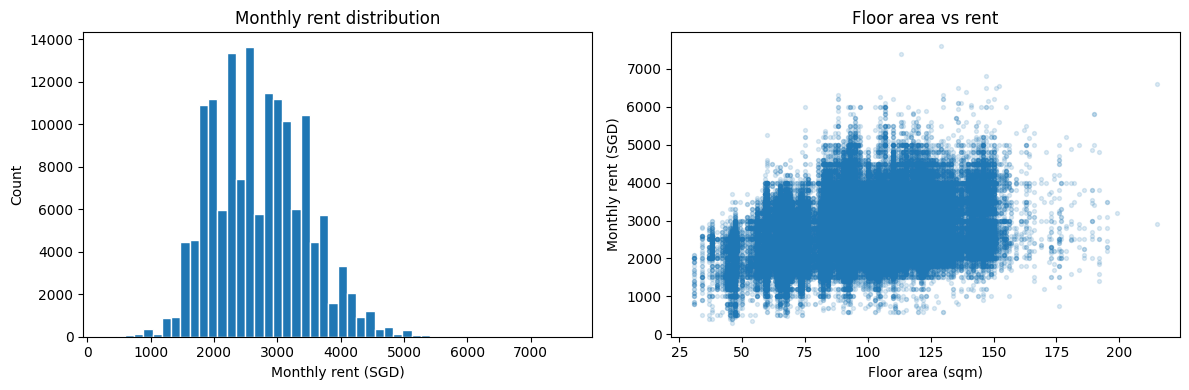

In [4]:
# ===== 根据实际 CSV 修改这里 =====
TARGET = "MONTHLY_RENT"
DATE_COL = "RENT_APPROVAL_DATE"
AREA_COL = "FLOOR_AREA_SQM"
LEASE_COL = "LEASE_COMMENCE_DATE"

CAT_COLS = ["TOWN", "FLAT_TYPE"]

# 只有确认这是提交用的记录 ID 时才填写；没有则填 None
ID_COL = None
# 例如：ID_COL = "Id"
# ================================

required_features = [DATE_COL, AREA_COL, LEASE_COL] + CAT_COLS

for name, df in [("train", train), ("test", test)]:
    missing = set(required_features) - set(df.columns)
    assert not missing, f"{name} 缺少这些列，请修改配置：{missing}"

assert TARGET in train.columns, f"训练集中没有目标列 {TARGET}"

# 目标值转为数值；不对缺失的租金做填充
y = pd.to_numeric(train[TARGET], errors="coerce")

if y.isna().any() or not np.isfinite(y).all():
    raise ValueError("租金列包含缺失值或非数值，请检查原始数据。")

display(train[required_features + [TARGET]].isna().sum().to_frame("missing"))
display(y.describe().to_frame("monthly_rent"))

print("完全重复的行数:", train.duplicated().sum())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(y, bins=50, edgecolor="white")
axes[0].set_title("Monthly rent distribution")
axes[0].set_xlabel("Monthly rent (SGD)")
axes[0].set_ylabel("Count")

area = pd.to_numeric(train[AREA_COL], errors="coerce")
axes[1].scatter(area, y, s=8, alpha=0.15)
axes[1].set_xlabel("Floor area (sqm)")
axes[1].set_ylabel("Monthly rent (SGD)")
axes[1].set_title("Floor area vs rent")

plt.tight_layout()
plt.show()

In [5]:
def make_features(df):
    X = pd.DataFrame(index=df.index)

    dates = pd.to_datetime(df[DATE_COL], errors="coerce")

    if dates.isna().any():
        raise ValueError(
            f"{DATE_COL} 中存在无法解析的日期，请检查格式或缺失值。"
        )

    X["floor_area_sqm"] = pd.to_numeric(
        df[AREA_COL], errors="coerce"
    )

    # 假设该列保存四位数年份，例如 1998
    lease_year = pd.to_numeric(df[LEASE_COL], errors="coerce")
    X["flat_age"] = dates.dt.year - lease_year

    # 连续时间趋势：2021-01 -> 0，2021-02 -> 1
    X["month_index"] = (
        (dates.dt.year - 2021) * 12 + dates.dt.month - 1
    )

    for col in CAT_COLS:
        values = df[col].astype("string").str.strip().str.upper()
        values = values.replace("", pd.NA)
        X[col] = values.astype(object).where(values.notna(), np.nan)

    return X.replace([np.inf, -np.inf], np.nan)


X = make_features(train)
X_test = make_features(test)

NUM_COLS = ["floor_area_sqm", "flat_age", "month_index"]

display(X.head())
print("Features:", X.columns.tolist())

,floor_area_sqm,flat_age,month_index,TOWN,FLAT_TYPE
0,93.0,9,0,PUNGGOL,4 ROOM
1,110.0,20,0,SENGKANG,5 ROOM
2,65.0,45,0,QUEENSTOWN,3 ROOM
3,96.0,11,0,SENGKANG,4 ROOM
4,102.0,20,0,SEMBAWANG,4 ROOM


Features: ['floor_area_sqm', 'flat_age', 'month_index', 'TOWN', 'FLAT_TYPE']


In [6]:
SPLIT_MODE = "time"  # 可改为 "random"

if SPLIT_MODE == "time":
    dates = pd.to_datetime(train[DATE_COL])
    months = dates.dt.to_period("M")
    unique_months = sorted(months.unique())

    if len(unique_months) < 2:
        raise ValueError("月份数量不足，无法进行时间划分。")

    n_valid_months = max(1, int(np.ceil(len(unique_months) * 0.2)))
    cutoff = unique_months[-n_valid_months]

    train_mask = months < cutoff
    valid_mask = months >= cutoff

    X_train = X.loc[train_mask].copy()
    X_valid = X.loc[valid_mask].copy()
    y_train = y.loc[train_mask].copy()
    y_valid = y.loc[valid_mask].copy()

    print("Validation starts:", cutoff)

elif SPLIT_MODE == "random":
    X_train, X_valid, y_train, y_valid = train_test_split(
        X, y, test_size=0.2, random_state=SEED
    )
else:
    raise ValueError("SPLIT_MODE 必须为 time 或 random")

print("Training rows:", len(X_train))
print("Validation rows:", len(X_valid))

Validation starts: 2024-05
Training rows: 117988
Validation rows: 32012


In [7]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(
        strategy="constant",
        fill_value="MISSING"
    )),
    ("onehot", OneHotEncoder(
        handle_unknown="ignore",
        drop="first"
    )),
])

preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, NUM_COLS),
    ("categorical", categorical_pipeline, CAT_COLS),
])

model = Pipeline([
    ("preprocess", preprocessor),
    ("regressor", LinearRegression()),
])

model.fit(X_train, y_train)

train_pred = model.predict(X_train)
valid_pred = model.predict(X_valid)

In [8]:
def evaluate(y_true, y_pred):
    return {
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAE": mean_absolute_error(y_true, y_pred),
        "R2": r2_score(y_true, y_pred),
    }


# 最简单的参照模型：始终预测训练集租金均值
dummy = DummyRegressor(strategy="mean")
dummy.fit(np.zeros((len(y_train), 1)), y_train)
dummy_pred = dummy.predict(np.zeros((len(y_valid), 1)))

results = pd.DataFrame({
    "Mean baseline / validation": evaluate(y_valid, dummy_pred),
    "Linear regression / training": evaluate(y_train, train_pred),
    "Linear regression / validation": evaluate(y_valid, valid_pred),
}).T

display(results.round(3))

,RMSE,MAE,R2
Mean baseline / validation,839.608,683.051,-0.633
Linear regression / training,507.888,388.854,0.522
Linear regression / validation,601.088,444.586,0.163


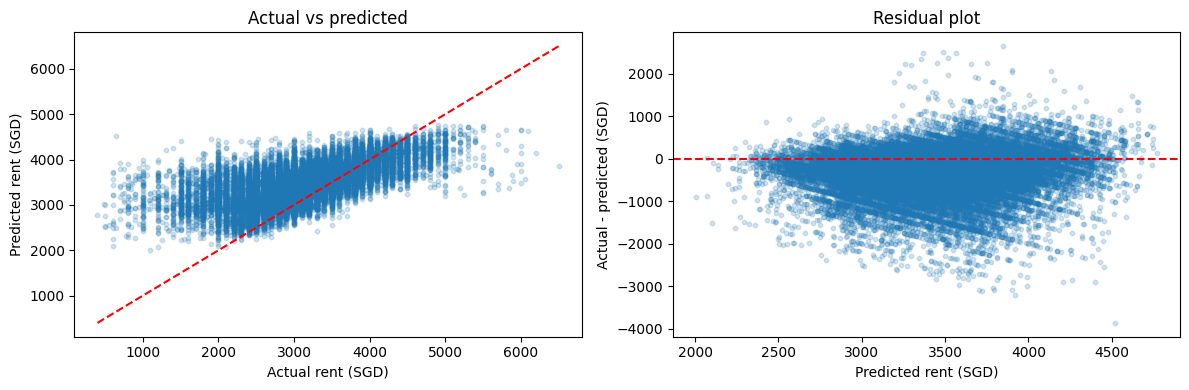

,sample_count,MAE
TOWN,,
CENTRAL,483,510.798284
KALLANG/WHAMPOA,1244,474.380630
BUKIT MERAH,1857,470.859190
QUEENSTOWN,1335,466.649155
JURONG WEST,2247,465.378225
GEYLANG,928,464.854090
BUKIT TIMAH,88,460.830399
BUKIT PANJANG,748,456.469442
JURONG EAST,845,453.910334


In [9]:
residuals = y_valid.to_numpy() - valid_pred

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(y_valid, valid_pred, s=10, alpha=0.2)

low = min(y_valid.min(), valid_pred.min())
high = max(y_valid.max(), valid_pred.max())
axes[0].plot([low, high], [low, high], "r--")

axes[0].set_xlabel("Actual rent (SGD)")
axes[0].set_ylabel("Predicted rent (SGD)")
axes[0].set_title("Actual vs predicted")

axes[1].scatter(valid_pred, residuals, s=10, alpha=0.2)
axes[1].axhline(0, color="red", linestyle="--")
axes[1].set_xlabel("Predicted rent (SGD)")
axes[1].set_ylabel("Actual - predicted (SGD)")
axes[1].set_title("Residual plot")

plt.tight_layout()
plt.show()

error_table = pd.DataFrame({
    "actual": y_valid,
    "predicted": valid_pred,
    "absolute_error": np.abs(residuals),
    CAT_COLS[0]: X_valid[CAT_COLS[0]],
})

group_errors = (
    error_table.groupby(CAT_COLS[0], dropna=False)
    .agg(
        sample_count=("absolute_error", "size"),
        MAE=("absolute_error", "mean")
    )
    .sort_values("MAE", ascending=False)
)

display(group_errors)

In [10]:
final_model = clone(model)
final_model.fit(X, y)

test_pred = final_model.predict(X_test)

assert len(test_pred) == len(test)
assert np.isfinite(test_pred).all()

print(pd.Series(test_pred, name="predicted_rent").describe())
print("Negative predictions:", int((test_pred < 0).sum()))

count    50000.000000
mean      3532.523687
std        405.432999
min       1951.220857
25%       3245.752754
50%       3557.536230
75%       3796.539367
max       4884.886662
Name: predicted_rent, dtype: float64
Negative predictions: 0


In [18]:
# predict 输出顺序与 X_test 的行顺序一致
# 前面的 make_features(test) 保留了 test 的原始顺序
test_pred = final_model.predict(X_test)

submission = pd.read_csv("/content/example-submission.csv")

print("提交模板列名：", submission.columns.tolist())
display(submission.head())

# 改成模板中实际要求填写租金预测的列名
PREDICTION_COL = "Predicted"

assert PREDICTION_COL in submission.columns
assert len(submission) == len(test_pred)
assert np.isfinite(test_pred).all()

# 按位置赋值；前提是模板与 test 按相同行顺序对应
submission[PREDICTION_COL] = test_pred

submission.to_csv("/content/submission.csv", index=False)
display(submission.head())

files.download("/content/submission.csv")

提交模板列名： ['Id', 'Predicted']


,Id,Predicted
0,0,2400.0
1,1,5500.0
2,2,2100.0
3,3,3900.0
4,4,3300.0


,Id,Predicted
0,0,3094.504015
1,1,3612.048558
2,2,3389.404011
3,3,3314.815680
4,4,3734.211477


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>